In [1]:
import pandas as pd
import numpy as np

In [2]:
pip install matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [9]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

In [15]:
df_raw = pd.read_csv("cleaned_data.csv")  

rename_map = {
    'Athlete': 'athlete',
    'DOB': 'dob',
    'Region': 'region',
    'School': 'school',
    'Level': 'level',
    'VT High': 'vt_high',
    'UB High': 'ub_high',
    'BB High': 'bb_high',
    'FX High': 'fx_high',
    'AA High': 'aa_high',
    'gym insta': 'gym_insta',
    'personal insta': 'personal_insta',
    'Club Gym': 'club_gym',
    'State': 'state',
    'Year': 'year',           # season year 
    'Class': 'grad_year',     # recruiting/HS grad class: this is what we group by
    'Country': 'country',
    'IsElite': 'is_elite',
    'Rating': 'rating',
    'HasPerfect10': 'has_perfect10'
}

# 1) Trim original names and rename exactly
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns=rename_map)

# 2) Validate 
required = [
    'athlete', 'dob', 'region', 'school', 'level',
    'vt_high','ub_high','bb_high','fx_high','aa_high',
    'club_gym','state','grad_year','country','is_elite','rating','has_perfect10'
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}\nHave: {df.columns.tolist()}")

# 3) Light cleanup: strip strings / unify case for categoricals
for c in ['athlete','region','school','level','club_gym','state','country','gym_insta','personal_insta']:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# 4) Types
# dates
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

# numerics
for c in ['vt_high','ub_high','bb_high','fx_high','aa_high','rating','year','grad_year']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# booleans (accept many truthy/falsey forms)
def to_bool(x):
    if isinstance(x, str):
        x = x.strip().lower()
        return x in ('1','y','yes','true','t')
    return bool(x) if pd.notna(x) else False

df['is_elite'] = df['is_elite'].apply(to_bool)
df['has_perfect10'] = df['has_perfect10'].apply(to_bool)

# Optionally persist a fast, clean copy for other notebooks
df.to_parquet("data/cleaned_recruits.parquet", index=False)
df.head(3)

,athlete,dob,region,school,level,vt_high,ub_high,bb_high,fx_high,aa_high,gym_insta,personal_insta,club_gym,state,year,grad_year,country,is_elite,rating,has_perfect10
0,Merideth Brandt,2007-04-08,6,Nebraska,10,NaN,NaN,NaN,NaN,NaN,https://www.instagram.com/meridethbrandtgymnas...,https://www.instagram.com/merideth.brandt/,Yellow Jackets,MA,2024.0,2025,USA,False,NaN,False
1,Shyla Bhatia,2007-07-02,7,Denver,10,9.775,9.575,9.425,9.85,38.350,https://www.instagram.com/shylabhatia2025/,https://www.instagram.com/missy_miss_demeaner/,Silvia's,PA,2024.0,2025,USA,False,9.65625,False
2,Sevana Kasparian,2007-07-25,1,Denver,10,9.700,9.825,9.600,9.70,38.275,https://www.instagram.com/sevanakasparian2025/,nan,Gymnastics Olympica,CA,2025.0,2025,USA,False,9.70625,False


In [17]:
score_cols = ["vt_high", "ub_high", "bb_high", "fx_high", "aa_high", "rating"]

df[score_cols] = df[score_cols].fillna(0)
df.head(3)

,athlete,dob,region,school,level,vt_high,ub_high,bb_high,fx_high,aa_high,gym_insta,personal_insta,club_gym,state,year,grad_year,country,is_elite,rating,has_perfect10
0,Merideth Brandt,2007-04-08,6,Nebraska,10,0.000,0.000,0.000,0.00,0.000,https://www.instagram.com/meridethbrandtgymnas...,https://www.instagram.com/merideth.brandt/,Yellow Jackets,MA,2024.0,2025,USA,False,0.00000,False
1,Shyla Bhatia,2007-07-02,7,Denver,10,9.775,9.575,9.425,9.85,38.350,https://www.instagram.com/shylabhatia2025/,https://www.instagram.com/missy_miss_demeaner/,Silvia's,PA,2024.0,2025,USA,False,9.65625,False
2,Sevana Kasparian,2007-07-25,1,Denver,10,9.700,9.825,9.600,9.70,38.275,https://www.instagram.com/sevanakasparian2025/,nan,Gymnastics Olympica,CA,2025.0,2025,USA,False,9.70625,False


In [18]:
# Convert region to numeric (non-numeric becomes NaN)
df['region'] = pd.to_numeric(df['region'], errors='coerce')

# Keep only rows where region is 1 through 8
df = df[df['region'].between(1, 8)]

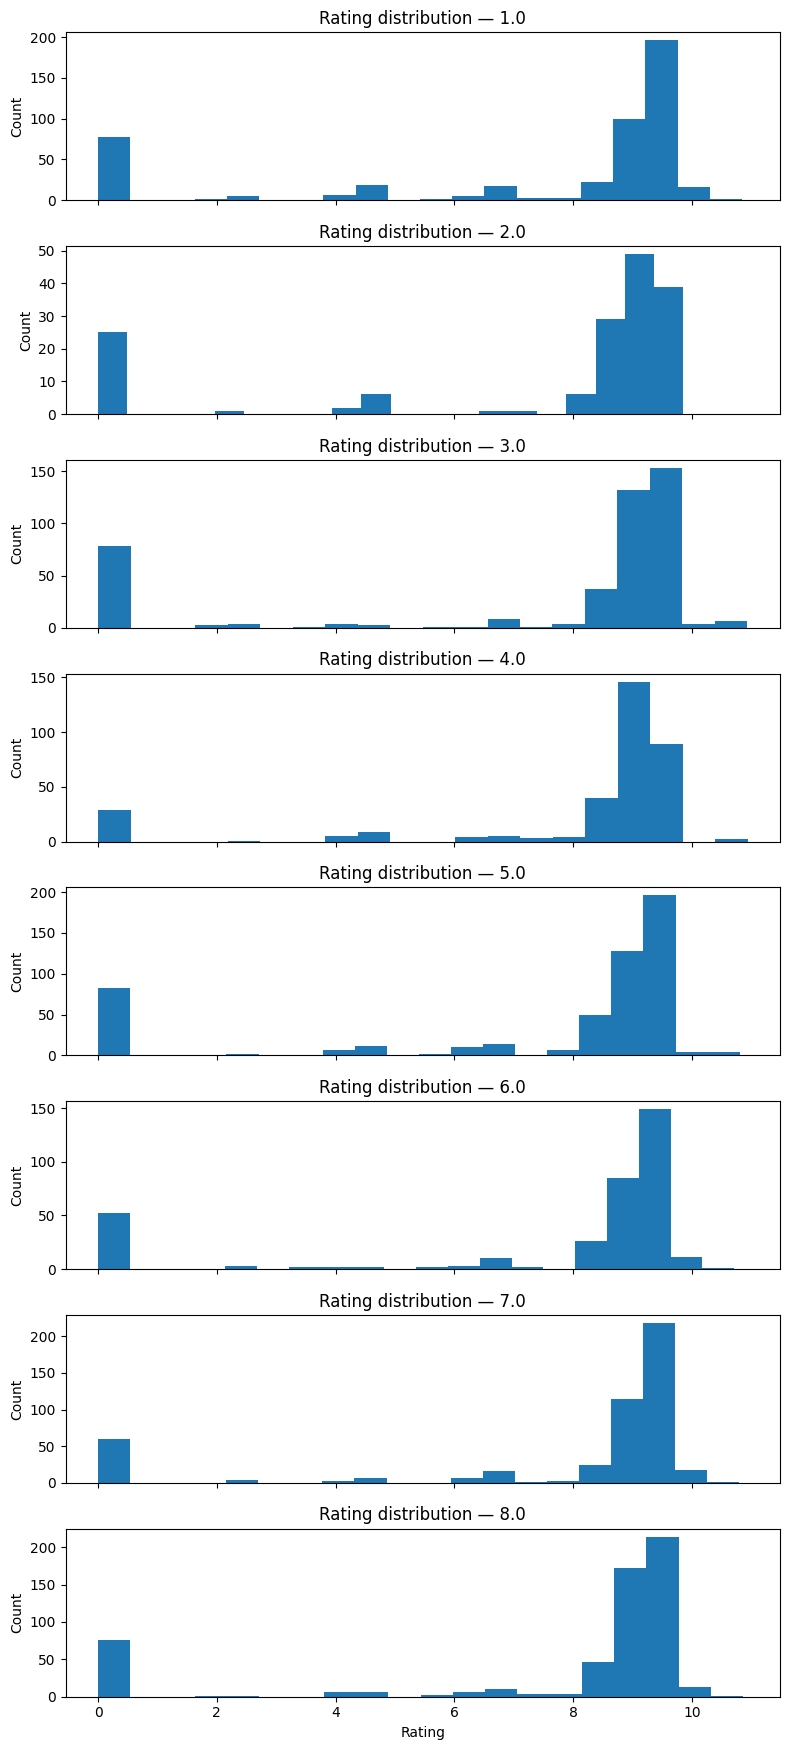

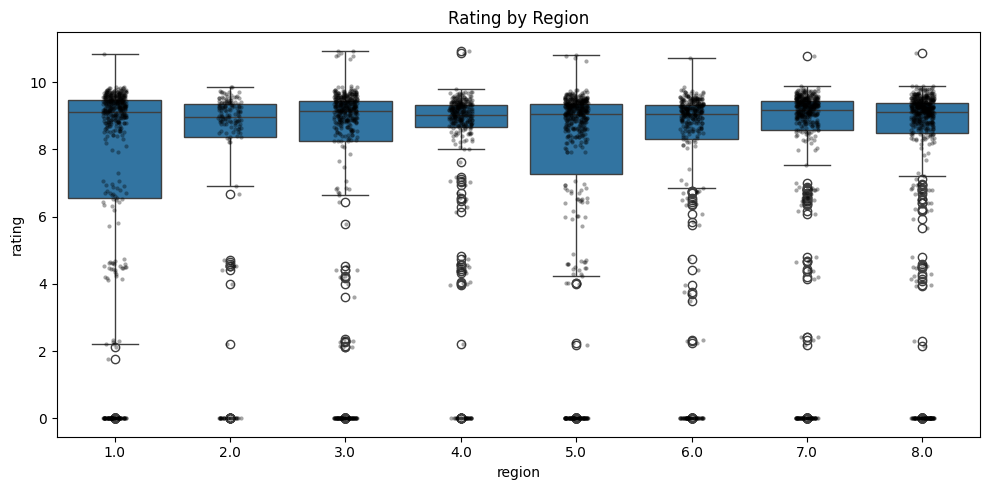

In [19]:
# Matplotlib histogram per region
regions = sorted(df['region'].dropna().unique())
fig, axes = plt.subplots(len(regions), 1, figsize=(8, 2.2*len(regions)), sharex=True)
if len(regions) == 1: axes = [axes]
for ax, r in zip(axes, regions):
    vals = df.loc[df['region']==r, 'rating'].dropna()
    ax.hist(vals, bins=20)
    ax.set_title(f"Rating distribution — {r}")
    ax.set_ylabel("Count")
axes[-1].set_xlabel("Rating")
plt.tight_layout()
plt.show()

# Seaborn box + jitter
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='region', y='rating')
sns.stripplot(data=df, x='region', y='rating', alpha=0.35, size=3, color='k')
plt.title("Rating by Region")
plt.tight_layout(); plt.show()

# Plotly violin (interactive)
fig = px.violin(df, x="region", y="rating", box=True, points="all", title="Rating by Region")
fig.show()


In [20]:
for c in ['region', 'level', 'school_commit']:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

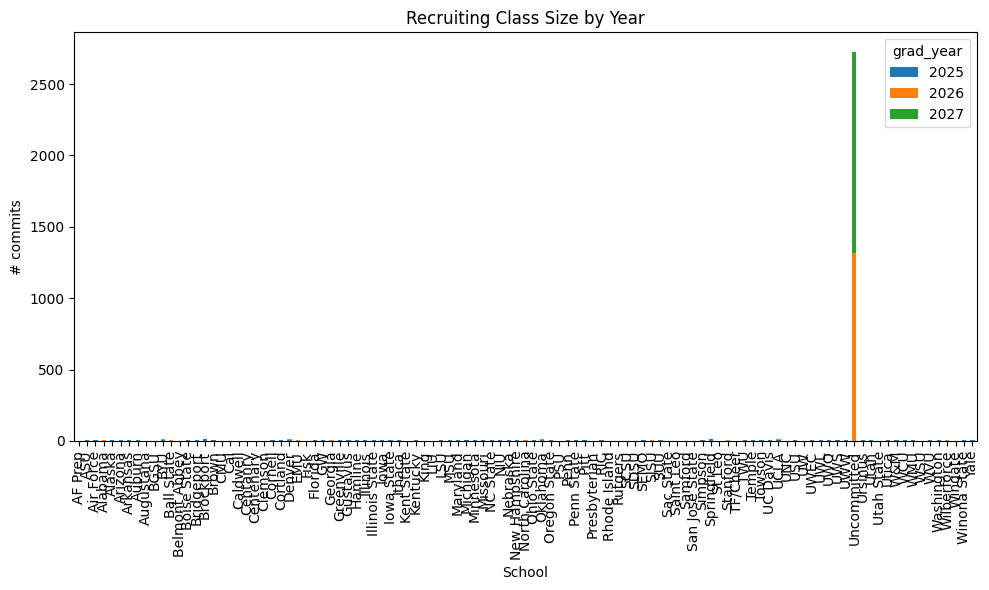

In [21]:
# Keep only rows that have a school (committed or target)
commits = df[df['school'].notna() & (df['school'] != '')].copy()

# Aggregates: size & strength of each class
agg = (commits
       .groupby(['school','grad_year'])
       .agg(n_commits=('athlete','count'),
            avg_rating=('rating','mean'),
            med_rating=('rating','median'))
       .reset_index()
       .sort_values(['school','grad_year']))
agg.head()

# Stacked bar: class size per school by year
counts = (commits
          .groupby(['school','grad_year'])['athlete']
          .count()
          .unstack(fill_value=0))
counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Recruiting Class Size by Year")
plt.xlabel("School"); plt.ylabel("# commits")
plt.tight_layout(); plt.show()

# Composition by level (stacked bars)
lvl_counts = (commits
              .groupby(['school','level'])['athlete']
              .count()
              .reset_index())
fig = px.bar(lvl_counts, x='school', y='athlete', color='level',
             title="Commit Composition by Level")
fig.show()

# Trend: average rating per school across grad_year
avg_by_year = (commits
               .groupby(['school','grad_year'])['rating']
               .mean()
               .reset_index())
fig = px.line(avg_by_year, x='grad_year', y='rating', color='school',
              markers=True, title="Avg Rating by Class Year (per School)")
fig.show()


In [24]:
def top_prospects(data, level=None, grad_year=None, k=10, by='rating'):
    q = data.copy()
    if level is not None:
        q = q[q['level'].str.lower() == str(level).lower()]
    if grad_year is not None:
        q = q[q['grad_year'] == grad_year]
    return (q
            .sort_values(by=by, ascending=False)
            .loc[:, ['athlete','level','grad_year','region','state','country','rating',
                     'vt_high','ub_high','bb_high','fx_high','aa_high','school','is_elite','has_perfect10']]
            .head(k))

display(top_prospects(df, level="Elite", grad_year=2027, k=10))
display(top_prospects(df, level="Level 10", grad_year=2026, k=10))
display(top_prospects(df, grad_year=2025, k=10))


,athlete,level,grad_year,region,state,country,rating,vt_high,ub_high,bb_high,fx_high,aa_high,school,is_elite,has_perfect10
3906,Halle Wittenberg,Elite,2027,3.0,TX,USA,9.78125,9.80,9.6,9.875,9.85,38.675,Uncommitted,True,False
3560,Madeline Simpson,Elite,2027,7.0,NJ,USA,9.72500,9.85,9.6,9.750,9.70,38.775,Uncommitted,True,False
3286,Tatum Drusch,Elite,2027,4.0,MN,USA,0.00000,0.00,0.0,0.000,0.00,0.000,Uncommitted,True,False
3499,Harlow Buddendeck,Elite,2027,6.0,NY,USA,0.00000,0.00,0.0,0.000,0.00,0.000,Uncommitted,True,False
3559,Camie Westerman,Elite,2027,7.0,MD,USA,0.00000,0.00,0.0,0.000,0.00,0.000,Uncommitted,True,False
3903,Tyler Turner,Elite,2027,3.0,TX,USA,0.00000,0.00,0.0,0.000,0.00,0.000,Uncommitted,True,False
3904,Reese Esponda,Elite,2027,3.0,TX,USA,0.00000,0.00,0.0,0.000,0.00,0.000,Uncommitted,True,False
3905,Cambry Haynes,Elite,2027,3.0,CO,USA,0.00000,0.00,0.0,0.000,0.00,0.000,Uncommitted,True,False
3907,Claire Pease,Elite,2027,3.0,TX,USA,0.00000,0.00,0.0,0.000,0.00,0.000,Uncommitted,True,False
3908,Sage Bradford,Elite,2027,3.0,TX,USA,0.00000,0.00,0.0,0.000,0.00,0.000,Uncommitted,True,False


,athlete,level,grad_year,region,state,country,rating,vt_high,ub_high,bb_high,fx_high,aa_high,school,is_elite,has_perfect10


,athlete,level,grad_year,region,state,country,rating,vt_high,ub_high,bb_high,fx_high,aa_high,school,is_elite,has_perfect10
40,Allison Cucci,10,2025,4.0,MN,USA,10.93750,10.000,9.925,9.950,9.875,38.975,Arkansas,False,True
7,Kamila Pawlak,10,2025,3.0,TX,USA,10.92500,10.000,9.975,9.800,9.925,39.075,Oklahoma,False,True
47,Haley Mustari,10,2025,3.0,OK,USA,10.88125,9.725,10.000,10.000,9.800,39.100,LSU,False,True
237,Celeste Field,10,2025,6.0,NY,USA,10.71250,10.000,9.550,9.600,9.700,38.200,Clemson,False,True
13,Bailey Stroud,10,2025,5.0,IN,USA,10.70625,9.600,10.000,9.625,9.600,38.375,Utah,False,True
63,Sophia Diaz,10,2025,7.0,MD,USA,9.90000,9.875,9.900,9.875,9.950,39.225,Michigan,False,False
10,Jocelyn Sasson,10,2025,8.0,FL,USA,9.87500,9.875,9.900,9.875,9.850,39.100,Florida,False,False
38,Nina Ballou,10,2025,8.0,FL,USA,9.87500,9.975,9.900,9.700,9.925,39.150,LSU,False,False
27,Mackenzie Estep,10,2025,2.0,WA,USA,9.85625,9.950,9.875,9.750,9.850,39.225,Oklahoma,False,False
45,Avalon Campbell,10,2025,1.0,CA,USA,9.84375,9.875,9.800,9.925,9.775,38.850,Arkansas,False,False


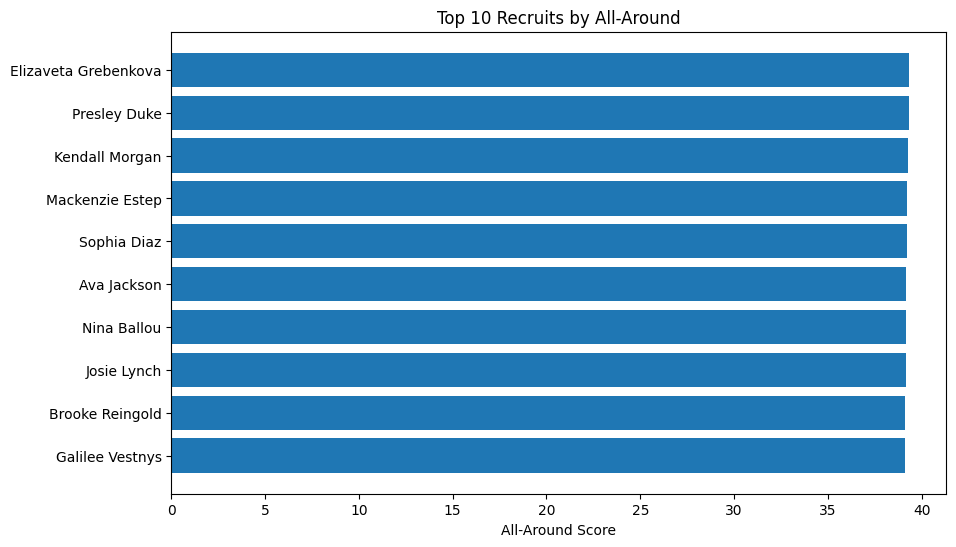

In [25]:
top_aa = df.nlargest(10, 'aa_high')[['athlete', 'aa_high']]

plt.figure(figsize=(10,6))
plt.barh(top_aa['athlete'], top_aa['aa_high'])
plt.xlabel('All-Around Score')
plt.title('Top 10 Recruits by All-Around')
plt.gca().invert_yaxis()
plt.show()

In [26]:
import plotly.express as px

fig = px.histogram(df, x="region", title="Distribution of Recruits by Region")
fig.show()

In [ ]:
pip install fastparquet


In [ ]:
pip install --upgrade pip

In [ ]:
pip install pyarrow 

In [ ]:
pip install -U pyarrow